In [1]:
# from models.imagenet import mobilenetv2
from  models.imagenet.mbnetv2 import mbnetv2
import torch
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
# from pathlib import Path
import logging
# from typing import Dict, List, Tuple, Optional
# from tqdm import tqdm
import math, os
import pandas as pd
# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [2]:
# mnet = mbnetv2()

In [3]:
cfgs = [
            [1,  16, 1, 1],
            [6,  24, 2, 2],
            [6,  32, 3, 2],
            [6,  64, 4, 2],
            
            [6,  96, 3, 1],
            [6, 160, 3, 2],
            [6, 320, 1, 1],
        ]
cfgs = [cfg[2] for cfg in cfgs]

In [4]:
type(cfgs)

list

In [5]:
def convert_state_dict(pretrained_sd,cfgs):
    new_sd = {}
    for k, v in pretrained_sd.items():
        # print(f"Converting {k} to ")
        # print(v)
        # First layer mapping
        if k.startswith('features.0'):
            new_key = k.replace('features.0', 'first_conv')
            new_sd[new_key] = v
        # Bottleneck blocks mapping (may need to adjust for all indices)
        elif k.startswith('features'):
            parts = k.split('.')
            block_idx = int(parts[1]) - 1      # because features.0 is first_conv
            # Find the corresponding config
            idx_1 = 0
            idx_2 = 0
            for i, cfg in enumerate(cfgs):
                if sum(cfgs[:i+1]) > block_idx:
                    idx_1 = i
                    idx_2 = block_idx - sum(cfgs[:i])
                    break

            rest = '.'.join(parts[2:])
            new_key = f'bottleneck_sequential_blocks.{idx_1}.{idx_2}.{rest}'
            new_sd[new_key] = v
        # Last layers mapping (if present)
        elif k.startswith('conv'):
            new_sd[k] = v
        elif k.startswith('classifier'):
            new_sd[k] = v
        else:
            # Handle or ignore unexpected keys
            pass
    return new_sd

In [6]:
pretrained_sd = torch.load('pretrained/mobilenetv2-c5e733a8.pth')
# converted_sd = convert_state_dict(pretrained_sd, cfgs)
# mnet.load_state_dict(converted_sd)


/tmp/ipykernel_235522/2419104990.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_sd = torch.load('pretrained/mobilenetv2-c5e733a8.pth')


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = model.to(device)

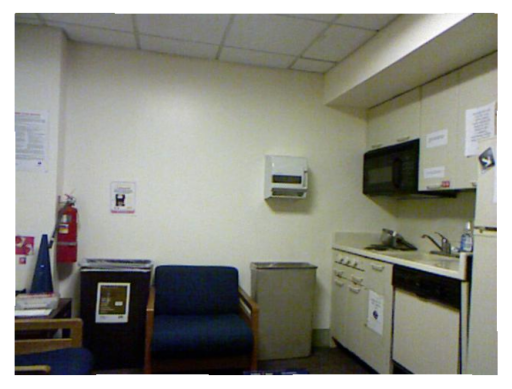

In [8]:

# Load image
img_path = '../nyu_data/data/nyu2_test/00000_colors.png'
img = Image.open(img_path).convert('RGB')

# Display the image
plt.imshow(img)
plt.axis('off')
plt.show()
# Define transforms matching training input requirements
# input_size = 224  # or your chosen input size
transform = transforms.Compose([
    # transforms.Resize(input_size),
    # transforms.CenterCrop(input_size),
    transforms.ToTensor() #,
    # transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet means
                        #  std=[0.229, 0.224, 0.225])   # ImageNet stds
])

# Apply transforms
img_tensor = transform(img).unsqueeze(0)  # add batch dimension

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
img_tensor = img_tensor.to(device)


# mnet.eval()
# mnet = mnet.to(device)
# # Forward pass
# with torch.no_grad():
#   output = mnet(img_tensor)

# print(output)  # raw model outputs (logits)


### Input and Encoder Stage Tensors


In [9]:
# print("Starting image:", img.size)
# print("Input tensor shape:", img_tensor.shape)
# for i in range(len(output[1])):
#     print(f"{i+1}th bottleneck output: {output[1][i].size()}")

### Model Classes


In [10]:
def conv_3x3_bn(inp, oup, stride):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 3, stride, 1, bias=False),
        nn.BatchNorm2d(oup),
        nn.ReLU6(inplace=True)
    )


def conv_1x1_bn(inp, oup):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 1, 1, 0, bias=False),
        nn.BatchNorm2d(oup),
        nn.ReLU6(inplace=True)
    )


class InvertedResidual(nn.Module):
    def __init__(self, inp, oup, stride, expand_ratio):
        super(InvertedResidual, self).__init__()
        assert stride in [1, 2]

        hidden_dim = round(inp * expand_ratio)
        self.identity = stride == 1 and inp == oup

        if expand_ratio == 1:
            self.conv = nn.Sequential(
                # dw
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                # pw-linear
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )
        else:
            self.conv = nn.Sequential(
                # pw
                nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                # dw
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                # pw-linear
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )
    
    def forward(self, x):
        if self.identity:
            return x + self.conv(x)
        else:
            return self.conv(x)

In [11]:
class PixelShuffleX2(nn.Module):
    def __init__(self, upscale_factor=2):
        super().__init__()
        self.ps = nn.PixelShuffle(upscale_factor)

    def forward(self, x):
        x = self.ps(x)
        return x

In [12]:
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        pixel = PixelShuffleX2
        bottleneck = InvertedResidual

        self.layer1 = nn.Sequential(
            pixel(2),
            bottleneck(80, 24, stride=1, expand_ratio=1),
            bottleneck(24, 24, stride=1, expand_ratio=6),
            bottleneck(24, 24, stride=1, expand_ratio=6),
            bottleneck(24, 24, stride=1, expand_ratio=6)
        )
        self.depth_conv_1 = nn.Conv2d(24, 1,kernel_size=1,bias=False)
        self.segm_conv_1 = nn.Conv2d(24, 19, kernel_size=1,bias=False)

        self.layer2 = nn.Sequential(
            pixel(2),
            bottleneck(30, 16, stride=1, expand_ratio=3),
            bottleneck(16, 16, stride=1, expand_ratio=6),
            bottleneck(16, 16, stride=1, expand_ratio=6)
        )
        self.depth_conv_2 = nn.Conv2d(16, 1,kernel_size=1,bias=False)
        self.segm_conv_2 = nn.Conv2d(16, 19, kernel_size=1,bias=False)


        self.layer3 = nn.Sequential(
            pixel(2),
            bottleneck(12, 8, stride=1, expand_ratio=6),
            bottleneck(8, 8, stride=1, expand_ratio=6),
            bottleneck(8, 8, stride=1, expand_ratio=6)
        )
        self.depth_conv_3 = nn.Conv2d(8, 1,kernel_size=1,bias=False)
        self.segm_conv_3 = nn.Conv2d(8, 19, kernel_size=1,bias=False)

        self.layer4 = nn.Sequential(
            pixel(4),
            bottleneck(2, 8, stride=1, expand_ratio=6),
            bottleneck(8, 8, stride=1, expand_ratio=6)
        )
        self.depth_conv_4 = nn.Conv2d(8, 1,kernel_size=1,bias=False)
        self.segm_conv_4 = nn.Conv2d(8, 19, kernel_size=1,bias=False)

    def forward(self, x, skips):
        depth_imgs=[]
        segm_imgs=[]
        out1 = self.layer1(x)
        depth_imgs.append(self.depth_conv_1(out1))
        segm_imgs.append(F.softmax(self.segm_conv_1(out1), dim=1))

        out1 = torch.cat((out1, skips[4]), dim=1)  # Skip connection
        out2 = self.layer2(out1)
        depth_imgs.append(self.depth_conv_2(out2))
        segm_imgs.append(F.softmax(self.segm_conv_2(out2), dim=1))

        out2 = torch.cat((out2, skips[2]), dim=1)  # Skip connection
        out3 = self.layer3(out2)
        depth_imgs.append(self.depth_conv_3(out3))
        segm_imgs.append(F.softmax(self.segm_conv_3(out3), dim=1))

        out3 = torch.cat((out3, skips[1]), dim=1)  # Skip connection
        out4 = self.layer4(out3)
        depth_imgs.append(self.depth_conv_4(out4))
        segm_imgs.append(F.softmax(self.segm_conv_4(out4), dim=1))

        depth_imgs = [img.squeeze(dim=1) for img in depth_imgs]
        return depth_imgs

In [13]:
class MainModel(nn.Module):
    def __init__(self,pretrained_sd):
        super().__init__()
        self.encoder = mbnetv2()
        converted_sd = convert_state_dict(pretrained_sd, cfgs)
        self.encoder.load_state_dict(converted_sd)

        for i in self.encoder.parameters():
            i.requires_grad = False

        self.decoder = Decoder()

    def forward(self, x):
        enc_out = self.encoder(x)
        dec_out = self.decoder(enc_out[0], enc_out[1])
        return dec_out

In [14]:
model = MainModel(pretrained_sd)

Initializing weights...


In [15]:
model.to(device)


MainModel(
  (encoder): MobileNetV2(
    (first_conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (bottleneck_sequential_blocks): ModuleList(
      (0): Sequential(
        (0): InvertedResidual(
          (conv): Sequential(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
            (3): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
      )
      (1): Sequential(
        (0): InvertedResidual(
          (conv): Sequential(
            (0): Conv2d(16, 96, kernel_size=(1, 1), str

In [16]:
def depth_to_display(depth_1x1HW: torch.Tensor, cmap='inferno'):
    # depth_1x1HW: (1,1,H,W)
    d = depth_1x1HW.detach().cpu().float().squeeze(0).squeeze(0)   # (H,W)
    # remove NaN/Inf and clip robustly using percentiles
    a = d.numpy()
    a = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
    # robust range (ignore outliers)
    vmin, vmax = np.percentile(a, 2), np.percentile(a, 98)
    if vmax <= vmin:
        vmin, vmax = float(a.min()), float(a.max())
    a = np.clip(a, vmin, vmax)
    norm = (a - vmin) / (vmax - vmin + 1e-12)

    # grayscale uint8 for saving
    gray_u8 = (norm * 255).astype(np.uint8)

    # optional colored visualization
    plt.figure(figsize=(4,4))
    plt.imshow(norm, cmap=cmap)  # e.g., 'inferno', 'magma', 'turbo', 'viridis'
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return gray_u8  # HxW uint8


In [17]:
dec_out = model(img_tensor)

In [18]:
for i in dec_out:
    print(i.shape)

torch.Size([1, 30, 40])
torch.Size([1, 60, 80])
torch.Size([1, 120, 160])
torch.Size([1, 480, 640])


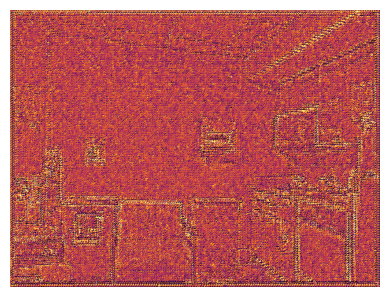

array([[ 94, 153, 174, ..., 138,  98,  64],
       [154, 197,  36, ..., 138,   7, 139],
       [124, 169, 162, ..., 127, 209,   0],
       ...,
       [215, 197,  74, ..., 116,  53, 255],
       [126, 105, 217, ..., 136, 164,   0],
       [150, 179,  49, ..., 146,  61, 116]], shape=(480, 640), dtype=uint8)

In [19]:
depth_to_display(dec_out[3])  # (1,1,H,W)

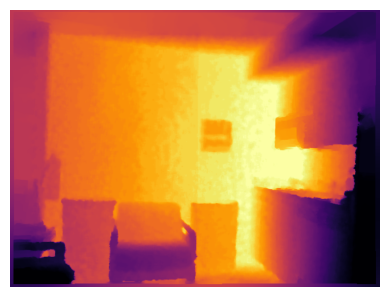

array([[129, 129, 129, ...,  46,  46,  46],
       [129, 129, 129, ...,  46,  46,  46],
       [129, 129, 129, ...,  46,  46,  46],
       ...,
       [ 39,  39,  39, ...,  20,  20,  20],
       [ 39,  39,  39, ...,  20,  20,  20],
       [ 39,  39,  39, ...,  20,  20,  20]], shape=(480, 640), dtype=uint8)

In [20]:
depth_path = '../nyu_data/data/nyu2_test/00000_depth.png'
gt_depth = Image.open(depth_path)
depth_tensor = transform(gt_depth).unsqueeze(0)  # add batch dimension
depth_tensor = depth_tensor.to(device)
# plt.imshow(gt_depth)
depth_to_display(depth_tensor)  # (1,1,H,W)


In [21]:
depth_tensor.shape

torch.Size([1, 1, 480, 640])

### LOSS FUNCTIONS


In [22]:
class DepthLoss(nn.Module):

    def __init__(self, m=4, M=80):
        super(DepthLoss, self).__init__()
        self.m = m  # lower bound for log transform
        self.M = M  # upper bound for log transform
    
    def log_transform(self, depth):

        log_depth = torch.log(torch.clamp(depth, min=self.m, max=self.M))
        log_m = math.log(self.m)
        log_M = math.log(self.M)
        
        return (log_depth - log_m) * self.M / (log_M - log_m)
    
    def berhu_loss(self, pred, target, c):
 
        diff = torch.abs(pred - target)
        l1_mask = diff <= c
        l1_loss = diff
        l2_loss = (diff**2 + c**2) / (2 * c)
        
        
        return torch.where(l1_mask, l1_loss, l2_loss)
    
    def forward(self, pred_depth, gt_depth):
        pred_log = self.log_transform(pred_depth)
        gt_log = self.log_transform(gt_depth)
        
        diff = torch.abs(pred_log - gt_log)
        c = 0.2 * torch.max(diff)  
        # Apply BerHu loss
        berhu_losses = self.berhu_loss(pred_log, gt_log, c)
        
        # Average over spatial dimensions
        B, H, W = pred_depth.shape
        loss = torch.sum(berhu_losses) / (B * H * W)
        
        return loss

## Dataset Prep


In [23]:
train_csv = '../nyu_data/data/nyu2_train.csv'
base_path = '../nyu_data'
df = pd.read_csv(train_csv, header=None)
df[0] = df[0].map(lambda x: base_path+"/"+x) # Prepending the base path
df[1] = df[1].map(lambda x: base_path+"/"+x)

In [24]:
df[0][0], df[1][0]  # Checking the paths

('../nyu_data/data/nyu2_train/living_room_0038_out/37.jpg',
 '../nyu_data/data/nyu2_train/living_room_0038_out/37.png')

In [25]:
class DepthDataset(Dataset):

    def __init__(self, df, image_transform=None, depth_transform=None):
    
        self.df = df
        self.image_transform = image_transform
        self.depth_transform = depth_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get the file paths from the dataframe at the given index
        image_path = self.df.iloc[idx][0]
        depth_path = self.df.iloc[idx][0]
        
        # Load the image and depth map using PIL
        # .convert('RGB') ensures the image has 3 channels
        image = transforms.ToTensor()(Image.open(image_path).convert('RGB'))
        # .convert('L') ensures the depth map is grayscale (1 channel)
        depth = transforms.ToTensor()(Image.open(depth_path).convert('L'))

        # Apply transformations if they are provided
        if self.image_transform:
            image = self.image_transform(image)
        
        if self.depth_transform:
            depth = self.depth_transform(depth)

        return image, depth

In [26]:
dataset_depth = DepthDataset(df)
data_loader_depth = DataLoader(dataset_depth, batch_size=8, shuffle=True, num_workers=2)
for batch in data_loader_depth:
    print(batch[0].shape)  # Should be (B, 3, H, W)
    print(batch[1].shape)  # Should be (B, 1, H, W)
    break

torch.Size([8, 3, 480, 640])
torch.Size([8, 1, 480, 640])


In [27]:
def train_multi_scale_depth_model(model, dataloader, num_epochs=100, lr=1e-4):
    # # Initialize dataset and dataloader
    # dataset = DepthDataset(dataset_folder)
    # dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize loss function and optimizer
    depth_loss = DepthLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Scale weights for different depth layers (coarse to fine)
    scale_weights = [0.5, 0.7, 0.9, 1.0]  # Give more weight to finer scales
    
    model.train()
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        
        for batch_idx, (color_input, depth_gt) in enumerate(dataloader):
            
            color_input = color_input.to(device, non_blocking=True)
            depth_gt = depth_gt.to(device, non_blocking=True)
            
            # Ensure data types are consistent
            color_input = color_input.float()
            depth_gt = depth_gt.float()
            
            optimizer.zero_grad()
            
            # Forward pass through model - returns list of 4 depth predictions
            depth_predictions = model(color_input)  # List of 4 tensors at different scales
            total_loss = 0.0
            
            layer_losses = []
            
            # Compute loss for each depth layer
            for i, (pred_depth, weight) in enumerate(zip(depth_predictions, scale_weights)):
                # Resize ground truth to match prediction resolution if needed
                # print("pred_depth shape:", pred_depth.shape)
                if pred_depth.shape[-2:] != depth_gt.shape[-2:]:
                    depth_gt_resized = torch.nn.functional.interpolate(
                        depth_gt, size=pred_depth.shape[-2:], mode='bilinear', align_corners=False
                    )
                else:
                    depth_gt_resized = depth_gt
                
                # Compute loss for this layer
                layer_loss = depth_loss(pred_depth, depth_gt_resized)
                weighted_loss = weight * layer_loss
                total_loss += weighted_loss
                layer_losses.append(layer_loss.item())
            
            # Backward pass
            total_loss.backward()
            optimizer.step()
            
            epoch_loss += total_loss.item()
            
            # Print progress
            if batch_idx % 10 == 0:
                print(f'Epoch {epoch}/{num_epochs}, Batch {batch_idx}, '
                      f'Total Loss: {total_loss.item():.4f}, '
                      f'Layer Losses: {[f"{l:.4f}" for l in layer_losses]}')
        
        print(f'Epoch {epoch} completed. Average Loss: {epoch_loss/len(dataloader):.4f}')

In [28]:
def train_multi_scale_depth_model_with_checks(model, dataset_folder, num_epochs=100, batch_size=4, lr=1e-4):
    # Explicit device checking
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print("CUDA is available! Training on GPU...")
    else:
        device = torch.device('cpu')
        print("CUDA is not available. Training on CPU...")
    
    # Move model to device
    # model = model.to(device)
    
    # Initialize dataset and dataloader
    dataset = DepthDataset(dataset_folder)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                          pin_memory=torch.cuda.is_available(), num_workers=2)
    
    # Initialize loss function and optimizer
    depth_loss = DepthLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Scale weights for different depth layers
    scale_weights = [0.5, 0.7, 0.9, 1.0]
    
    model.train()
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        
        for batch_idx, (color_input, depth_gt) in enumerate(dataloader):
            # Move tensors to GPU if CUDA is available
            color_input = color_input.to(device, non_blocking=True)
            depth_gt = depth_gt.to(device, non_blocking=True)
            
            # Ensure data types are consistent
            color_input = color_input.float()
            depth_gt = depth_gt.float()
            
            optimizer.zero_grad()
            
            # Forward pass through model
            depth_predictions = model(color_input)
            
            total_loss = 0.0
            layer_losses = []
            
            # Compute loss for each depth layer
            for i, (pred_depth, weight) in enumerate(zip(depth_predictions, scale_weights)):
                # Resize ground truth to match prediction resolution if needed
                if pred_depth.shape[-2:] != depth_gt.shape[-2:]:
                    depth_gt_resized = torch.nn.functional.interpolate(
                        depth_gt, size=pred_depth.shape[-2:], mode='bilinear', align_corners=False
                    )
                else:
                    depth_gt_resized = depth_gt
                
                # Compute loss for this layer
                layer_loss = depth_loss(pred_depth, depth_gt_resized)
                weighted_loss = weight * layer_loss
                total_loss += weighted_loss
                layer_losses.append(layer_loss.item())
            
            # Backward pass
            total_loss.backward()
            optimizer.step()
            
            epoch_loss += total_loss.item()
            
            # Print progress
            if batch_idx % 10 == 0:
                print(f'Epoch {epoch}/{num_epochs}, Batch {batch_idx}, '
                      f'Total Loss: {total_loss.item():.4f}, '
                      f'Device: {color_input.device}, '
                      f'Layer Losses: {[f"{l:.4f}" for l in layer_losses]}')
        
        print(f'Epoch {epoch} completed. Average Loss: {epoch_loss/len(dataloader):.4f}')



In [29]:
torch.cuda.empty_cache()

In [30]:
train_multi_scale_depth_model(model, data_loader_depth, num_epochs=5, lr=1e-4)

Epoch 0/5, Batch 0, Total Loss: 0.0210, Layer Losses: ['0.0000', '0.0000', '0.0228', '0.0004']
Epoch 0/5, Batch 10, Total Loss: 0.0107, Layer Losses: ['0.0106', '0.0000', '0.0058', '0.0001']
Epoch 0/5, Batch 20, Total Loss: 0.0029, Layer Losses: ['0.0000', '0.0000', '0.0031', '0.0001']
Epoch 0/5, Batch 30, Total Loss: 0.0010, Layer Losses: ['0.0000', '0.0000', '0.0010', '0.0000']
Epoch 0/5, Batch 40, Total Loss: 0.0014, Layer Losses: ['0.0004', '0.0000', '0.0013', '0.0001']
Epoch 0/5, Batch 50, Total Loss: 0.0007, Layer Losses: ['0.0000', '0.0000', '0.0007', '0.0000']
Epoch 0/5, Batch 60, Total Loss: 0.0000, Layer Losses: ['0.0000', '0.0000', '0.0000', '0.0000']
Epoch 0/5, Batch 70, Total Loss: 0.0010, Layer Losses: ['0.0000', '0.0000', '0.0010', '0.0000']
Epoch 0/5, Batch 80, Total Loss: 0.0003, Layer Losses: ['0.0000', '0.0000', '0.0004', '0.0000']


KeyboardInterrupt: 

In [ ]:
output = model(img_tensor)

In [ ]:
depth_to_display(output[3])  # (1,1,H,W)